In [2]:
from pathlib import Path
import pandas as pd

# Project directories
PROJECT_DIR = Path.cwd().parent
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

# Load metadata
df = pd.read_csv(DATA_DIR / "master_dataset.csv")

print(f"Metadata records: {len(df)}")
print(f"Processed directory: {PROCESSED_DIR}")

Metadata records: 36
Processed directory: c:\Users\User\Desktop\colonial-discourse-nlp\data\processed


In [3]:
# Load all raw article texts

articles = {}

for file in RAW_DIR.rglob("*.txt"):
    article_id = file.stem
    text = file.read_text(encoding="utf-8", errors="replace").strip()
    articles[article_id] = text

print(f"Articles loaded: {len(articles)}")

Articles loaded: 36


In [4]:
# Inspect a few raw articles before preprocessing

for article_id in ["IND01", "AUS03", "MAL07"]:
    print("=" * 80)
    print(article_id)
    print("=" * 80)
    print(articles[article_id][:1000])
    print("\n[...]\n")

IND01
UPLIFT OF HILL TRIBES—I By L. M. SHRIKANT, M.L.A.,EXCLUSION of hill tracts from the sphere of the Ministry is worse than separate electorates.It is an “amputation of the body politic.”The first official inquiry into the conditions of the Aboriginal and Hill Tribes of the Bombay Presidency was carried on by the Starte Committee appointed by the Government in 1928 on the recommendation of Mr. Solanki's resolution in the Legislative Council. Its Report was out in March 1930. This was the first time when the Aboriginal and Hill Tribes received an attention together with the Depressed classes now known as Scheduled class.The Starte Committee made a clear distinction between and devised generic nomenclature for "Untouchables", "Aboriginal Tribes" and other Backward classes and a new Intermediate class. The problem of the Aboriginal Tribes was not so thoroughly investigated as that of the scheduled classes, during that first inquiry.★Nine years later we have now before us the result of 

In [5]:
import re

def basic_clean(text):
    """
    Conservative cleaning for historical newspaper OCR.
    Preserves wording and punctuation while removing obvious
    formatting/OCR artefacts.
    """
    
    # Normalize line endings
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    
    # Remove obvious standalone OCR symbols
    text = text.replace("★", " ")
    
    # Normalize common curly quotation marks
    text = (
        text.replace("“", '"')
            .replace("”", '"')
            .replace("‘", "'")
            .replace("’", "'")
    )
    
    # Collapse repeated whitespace while preserving paragraph breaks
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    
    # Remove leading/trailing whitespace
    text = text.strip()
    
    return text


# Test the cleaning on the three sample articles
for article_id in ["IND01", "AUS03", "MAL07"]:
    cleaned = basic_clean(articles[article_id])
    
    print("=" * 80)
    print(article_id)
    print("=" * 80)
    print(cleaned[:1000])
    print("\n")

IND01
UPLIFT OF HILL TRIBES—I By L. M. SHRIKANT, M.L.A.,EXCLUSION of hill tracts from the sphere of the Ministry is worse than separate electorates.It is an "amputation of the body politic."The first official inquiry into the conditions of the Aboriginal and Hill Tribes of the Bombay Presidency was carried on by the Starte Committee appointed by the Government in 1928 on the recommendation of Mr. Solanki's resolution in the Legislative Council. Its Report was out in March 1930. This was the first time when the Aboriginal and Hill Tribes received an attention together with the Depressed classes now known as Scheduled class.The Starte Committee made a clear distinction between and devised generic nomenclature for "Untouchables", "Aboriginal Tribes" and other Backward classes and a new Intermediate class. The problem of the Aboriginal Tribes was not so thoroughly investigated as that of the scheduled classes, during that first inquiry. Nine years later we have now before us the result of 

In [6]:
# Compare raw and cleaned text across the entire corpus

cleaning_stats = []

for article_id, text in articles.items():
    cleaned = basic_clean(text)
    
    cleaning_stats.append({
        "article_id": article_id,
        "raw_characters": len(text),
        "cleaned_characters": len(cleaned),
        "characters_removed": len(text) - len(cleaned)
    })

cleaning_df = pd.DataFrame(cleaning_stats).sort_values(
    "characters_removed", ascending=False
)

display(cleaning_df)

print(f"Total raw characters: {cleaning_df['raw_characters'].sum():,}")
print(f"Total cleaned characters: {cleaning_df['cleaned_characters'].sum():,}")
print(f"Total characters removed: {cleaning_df['characters_removed'].sum():,}")

,article_id,raw_characters,cleaned_characters,characters_removed
0,AUS01,415,415,0
1,AUS02,1096,1096,0
2,AUS03,6749,6749,0
3,AUS04,936,936,0
4,AUS05,1008,1008,0
5,AUS06,303,303,0
6,AUS07,996,996,0
7,AUS08,4965,4965,0
8,AUS09,1942,1942,0
9,AUS10,2373,2373,0


Total raw characters: 97,233
Total cleaned characters: 97,233
Total characters removed: 0


In [7]:
# Look for likely OCR spacing problems

spacing_patterns = {
    "period_then_letter": r"\.[A-Za-z]",
    "comma_then_letter": r",[A-Za-z]",
    "colon_then_letter": r":[A-Za-z]",
    "semicolon_then_letter": r";[A-Za-z]",
    "question_then_letter": r"\?[A-Za-z]",
    "exclamation_then_letter": r"![A-Za-z]",
}

for name, pattern in spacing_patterns.items():
    total = 0
    
    for text in articles.values():
        total += len(re.findall(pattern, text))
    
    print(f"{name}: {total}")

period_then_letter: 295
comma_then_letter: 7
colon_then_letter: 1
semicolon_then_letter: 0
question_then_letter: 6
exclamation_then_letter: 4


In [8]:
# Inspect examples of possible missing spaces after full stops

period_matches = []

for article_id, text in articles.items():
    for match in re.finditer(r"\.[A-Za-z]", text):
        start = max(0, match.start() - 50)
        end = min(len(text), match.end() + 80)
        
        period_matches.append({
            "article_id": article_id,
            "context": text[start:end].replace("\n", " ")
        })

period_matches_df = pd.DataFrame(period_matches)

print(f"Total matches: {len(period_matches_df)}")
display(period_matches_df.head(50))

Total matches: 295


,article_id,context
0,AUS01,"""NO ADMISSION OF ABORIGINES.""MELBOURNE, Friday..."
1,AUS02,RECRUITING OF ABORIGINES.Mr. Hughes expressed ...
2,AUS02,"lot of men, and many aborigines served with t..."
3,AUS02,"ot of men, and many aborigines served with the..."
4,AUS02,"rolled in special units, but should be distrib..."
5,AUS03,NEW DEAL FOR NATIVES.DOOM SPELT BY CIVILISATIO...
6,AUS03,NEW DEAL FOR NATIVES.DOOM SPELT BY CIVILISATIO...
7,AUS03,.DOOM SPELT BY CIVILISATION.Reservations Essen...
8,AUS03,bsolutely unmolested in their own hunting grou...
9,AUS03,rting the continued destruction of the native ...


In [9]:
import re

def clean_ocr_spacing(text):
    """
    Conservative cleaning for historical newspaper OCR.

    Fixes obvious formatting/OCR artefacts while preserving
    historical wording and punctuation.
    """
    cleaned = text
    
    # Normalize line endings
    cleaned = cleaned.replace("\r\n", "\n").replace("\r", "\n")
    
    # Remove known OCR marker
    cleaned = cleaned.replace("★", " ")
    
    # Normalize curly quotation marks
    cleaned = (
        cleaned.replace("“", '"')
               .replace("”", '"')
               .replace("‘", "'")
               .replace("’", "'")
    )
    
    # Fix sentence-ending punctuation followed immediately
    # by a capital letter.
    cleaned = re.sub(r'([.!?])([A-Z])', r'\1 \2', cleaned)
    
    # Fix sentence-ending punctuation followed by a closing
    # quotation mark and then a capital letter.
    cleaned = re.sub(r'([.!?]["\'])([A-Z])', r'\1 \2', cleaned)
    
    # Fix confirmed OCR spacing errors
    cleaned = re.sub(
        r'1939malaya',
        '1939 Malaya',
        cleaned,
        flags=re.IGNORECASE
    )
    
    cleaned = re.sub(
        r'chellappahdistinguished',
        'chellappah distinguished',
        cleaned,
        flags=re.IGNORECASE
    )
    
    # Collapse repeated horizontal whitespace
    cleaned = re.sub(r'[ \t]+', ' ', cleaned)
    
    # Preserve paragraph structure
    cleaned = re.sub(r'\n{3,}', '\n\n', cleaned)
    
    return cleaned.strip()

In [10]:
for article_id in ["AUS01", "AUS03", "MAL07", "IND01"]:
    raw = articles[article_id]
    cleaned = clean_ocr_spacing(raw)
    
    print("=" * 80)
    print(article_id)
    print(cleaned[:700])
    print()

AUS01
"NO ADMISSION OF ABORIGINES." MELBOURNE, Friday. The Minister for Defence, Mr. Street, commenting on suggestions that aborigines should be admitted to the militia forces, said he had no intention of taking any action to enable this to be done. Under military regulations every person would be medically examined before enlistment. No person would be enlisted unless he was substantially of European origin or descent.

AUS03
NEW DEAL FOR NATIVES. DOOM SPELT BY CIVILISATION. Reservations Essential. BY ERNESTINE HILL.(Mrs. Hill, well-known author and traveller, is a keen student of the aborigines whose ways she studied during her wanderings in "The Great Australian Loneliness." She here expresses the case in favour of leaving the remnants of the tribes absolutely unmolested in their own hunting grounds). Elaborate schemes for a "new deal" for the aborigines are old as the history of white occupation, and however well-meaning the latest Commonwealth proposal may be, it offers little hop

In [11]:
from pathlib import Path

# Recreate the raw text file list
text_files = list(RAW_DIR.rglob("*.txt"))

# Create processed directory
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

processed_count = 0

for file in text_files:
    article_id = file.stem
    
    raw_text = articles[article_id]
    cleaned_text = clean_ocr_spacing(raw_text)
    
    output_file = PROCESSED_DIR / f"{article_id}.txt"
    output_file.write_text(cleaned_text, encoding="utf-8")
    
    processed_count += 1

print(f"Processed articles saved: {processed_count}")
print(f"Output directory: {PROCESSED_DIR}")

Processed articles saved: 36
Output directory: c:\Users\User\Desktop\colonial-discourse-nlp\data\processed


In [12]:
# Validate processed files against the raw corpus

processed_files = list(PROCESSED_DIR.glob("*.txt"))

print(f"Processed text files: {len(processed_files)}")

processed_ids = {file.stem for file in processed_files}
metadata_ids = set(df["article_id"].astype(str).str.strip())

print(f"Metadata IDs: {len(metadata_ids)}")
print(f"Processed IDs: {len(processed_ids)}")

print("\nMissing processed files:")
print(sorted(metadata_ids - processed_ids) if metadata_ids - processed_ids else "None")

print("\nExtra processed files:")
print(sorted(processed_ids - metadata_ids) if processed_ids - metadata_ids else "None")

Processed text files: 36
Metadata IDs: 36
Processed IDs: 36

Missing processed files:
None

Extra processed files:
None


In [13]:
# Load processed articles into a dataframe

processed_articles = []

for file in sorted(PROCESSED_DIR.glob("*.txt")):
    text = file.read_text(encoding="utf-8", errors="replace").strip()
    
    processed_articles.append({
        "article_id": file.stem,
        "text": text,
        "word_count": len(text.split()),
        "character_count": len(text)
    })

processed_df = pd.DataFrame(processed_articles)

print(f"Processed articles loaded: {len(processed_df)}")
print(f"Total words: {processed_df['word_count'].sum():,}")
print(f"Average words/article: {processed_df['word_count'].mean():,.0f}")
print(f"Shortest article: {processed_df['word_count'].min():,} words")
print(f"Longest article: {processed_df['word_count'].max():,} words")

display(processed_df.head())

Processed articles loaded: 36
Total words: 16,329
Average words/article: 454
Shortest article: 51 words
Longest article: 1,182 words


,article_id,text,word_count,character_count
0,AUS01,"""NO ADMISSION OF ABORIGINES."" MELBOURNE, Frida...",64,417
1,AUS02,RECRUITING OF ABORIGINES. Mr. Hughes expressed...,185,1102
2,AUS03,NEW DEAL FOR NATIVES. DOOM SPELT BY CIVILISATI...,1106,6770
3,AUS04,ABORIGINES IN COUNTRY. Discrimination by White...,146,942
4,AUS05,NEW ABORIGINAL POLICY. Commonwealth Plans. QUE...,158,1015


In [14]:
# Merge article text with the locked metadata

analysis_df = df.merge(
    processed_df[["article_id", "text", "word_count", "character_count"]],
    on="article_id",
    how="inner"
)

print(f"Analysis records: {len(analysis_df)}")
print(f"Columns: {analysis_df.columns.tolist()}")

print("\nArticles by country:")
print(analysis_df["country"].value_counts())

print("\nWords by country:")
print(
    analysis_df.groupby("country")["word_count"]
    .agg(["count", "sum", "mean", "median"])
)

Analysis records: 36
Columns: ['article_id', 'country', 'newspaper', 'date', 'page', 'title', 'theme', 'sub_theme', 'population', 'author', 'source_url', 'archive', 'ocr_quality', 'text', 'word_count', 'character_count']

Articles by country:
country
Australia         17
British Malaya    10
India              9
Name: count, dtype: int64

Words by country:
                count   sum        mean  median
country                                        
Australia          17  5574  327.882353   190.0
British Malaya     10  6303  630.300000   652.5
India               9  4452  494.666667   493.0


In [15]:
import nltk
import spacy
import sklearn

print("NLTK:", nltk.__version__)
print("spaCy:", spacy.__version__)
print("scikit-learn:", sklearn.__version__)

NLTK: 3.10.3
spaCy: 3.8.16
scikit-learn: 1.9.0


In [16]:
import nltk

nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [17]:
# Tokenize the processed corpus

from nltk.tokenize import word_tokenize

analysis_df["tokens"] = analysis_df["text"].apply(
    lambda text: word_tokenize(text)
)

print("Articles tokenized:", len(analysis_df))
print("Total tokens:", analysis_df["tokens"].apply(len).sum())

print("\nExample tokens from IND01:")
print(analysis_df.loc[analysis_df["article_id"] == "IND01", "tokens"].iloc[0][:100])

Articles tokenized: 36
Total tokens: 18445

Example tokens from IND01:
['UPLIFT', 'OF', 'HILL', 'TRIBES', '—', 'I', 'By', 'L.', 'M.', 'SHRIKANT', ',', 'M.', 'L.', 'A.', ',', 'EXCLUSION', 'of', 'hill', 'tracts', 'from', 'the', 'sphere', 'of', 'the', 'Ministry', 'is', 'worse', 'than', 'separate', 'electorates', '.', 'It', 'is', 'an', '``', 'amputation', 'of', 'the', 'body', 'politic', '.', "''", 'The', 'first', 'official', 'inquiry', 'into', 'the', 'conditions', 'of', 'the', 'Aboriginal', 'and', 'Hill', 'Tribes', 'of', 'the', 'Bombay', 'Presidency', 'was', 'carried', 'on', 'by', 'the', 'Starte', 'Committee', 'appointed', 'by', 'the', 'Government', 'in', '1928', 'on', 'the', 'recommendation', 'of', 'Mr.', 'Solanki', "'s", 'resolution', 'in', 'the', 'Legislative', 'Council', '.', 'Its', 'Report', 'was', 'out', 'in', 'March', '1930', '.', 'This', 'was', 'the', 'first', 'time', 'when', 'the']


In [18]:
# Inspect article titles against the beginning of the processed text

for article_id in ["IND01", "AUS03", "MAL07"]:
    row = analysis_df[analysis_df["article_id"] == article_id].iloc[0]
    
    print("=" * 80)
    print(article_id)
    print("METADATA TITLE:")
    print(row["title"])
    print("\nPROCESSED TEXT START:")
    print(row["text"][:500])
    print()

IND01
METADATA TITLE:
Uplift Of Hill Tribes

PROCESSED TEXT START:
UPLIFT OF HILL TRIBES—I By L. M. SHRIKANT, M. L. A.,EXCLUSION of hill tracts from the sphere of the Ministry is worse than separate electorates. It is an "amputation of the body politic." The first official inquiry into the conditions of the Aboriginal and Hill Tribes of the Bombay Presidency was carried on by the Starte Committee appointed by the Government in 1928 on the recommendation of Mr. Solanki's resolution in the Legislative Council. Its Report was out in March 1930. This was the first 

AUS03
METADATA TITLE:
New Deal For Natives

PROCESSED TEXT START:
NEW DEAL FOR NATIVES. DOOM SPELT BY CIVILISATION. Reservations Essential. BY ERNESTINE HILL.(Mrs. Hill, well-known author and traveller, is a keen student of the aborigines whose ways she studied during her wanderings in "The Great Australian Loneliness." She here expresses the case in favour of leaving the remnants of the tribes absolutely unmolested in their ow

In [19]:
# Create analysis tokens: words only, preserving historical wording

analysis_df["word_tokens"] = analysis_df["tokens"].apply(
    lambda tokens: [
        token.lower()
        for token in tokens
        if any(char.isalpha() for char in token)
    ]
)

print("Articles processed:", len(analysis_df))
print("Total word tokens:", analysis_df["word_tokens"].apply(len).sum())

print("\nExample from IND01:")
print(analysis_df.loc[
    analysis_df["article_id"] == "IND01",
    "word_tokens"
].iloc[0][:100])

Articles processed: 36
Total word tokens: 16375

Example from IND01:
['uplift', 'of', 'hill', 'tribes', 'i', 'by', 'l.', 'm.', 'shrikant', 'm.', 'l.', 'a.', 'exclusion', 'of', 'hill', 'tracts', 'from', 'the', 'sphere', 'of', 'the', 'ministry', 'is', 'worse', 'than', 'separate', 'electorates', 'it', 'is', 'an', 'amputation', 'of', 'the', 'body', 'politic', 'the', 'first', 'official', 'inquiry', 'into', 'the', 'conditions', 'of', 'the', 'aboriginal', 'and', 'hill', 'tribes', 'of', 'the', 'bombay', 'presidency', 'was', 'carried', 'on', 'by', 'the', 'starte', 'committee', 'appointed', 'by', 'the', 'government', 'in', 'on', 'the', 'recommendation', 'of', 'mr.', 'solanki', "'s", 'resolution', 'in', 'the', 'legislative', 'council', 'its', 'report', 'was', 'out', 'in', 'march', 'this', 'was', 'the', 'first', 'time', 'when', 'the', 'aboriginal', 'and', 'hill', 'tribes', 'received', 'an', 'attention', 'together', 'with', 'the', 'depressed']


In [20]:
from collections import Counter

# Count word frequencies across the full corpus

all_words = [
    word
    for tokens in analysis_df["word_tokens"]
    for word in tokens
]

word_counts = Counter(all_words)

print("Unique word types:", len(word_counts))
print("Total word tokens:", len(all_words))

print("\nTop 50 most frequent words:")
for word, count in word_counts.most_common(50):
    print(f"{word:<20} {count}")

Unique word types: 3751
Total word tokens: 16375

Top 50 most frequent words:
the                  1313
of                   719
to                   484
and                  462
in                   375
a                    302
that                 198
for                  185
is                   171
be                   166
by                   121
on                   110
it                   107
are                  107
not                  106
as                   99
from                 97
will                 96
was                  94
with                 91
he                   89
have                 86
which                85
at                   80
we                   79
this                 75
their                74
they                 71
i                    69
has                  67
or                   57
but                  55
an                   54
mr.                  54
had                  54
our                  53
been                 51
his               

In [21]:
# Check whether the NLTK English stopword list is available

from nltk.corpus import stopwords

try:
    english_stopwords = set(stopwords.words("english"))
    print(f"English stopwords loaded: {len(english_stopwords)}")
    print(sorted(list(english_stopwords))[:30])
except LookupError:
    print("Stopword resource not found. Downloading...")
    nltk.download("stopwords")
    english_stopwords = set(stopwords.words("english"))
    print(f"English stopwords loaded: {len(english_stopwords)}")

English stopwords loaded: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't"]


In [22]:
# Create a stopword-filtered token list for statistical analysis
# Original word_tokens remain unchanged.

analysis_df["filtered_tokens"] = analysis_df["word_tokens"].apply(
    lambda tokens: [
        token
        for token in tokens
        if token not in english_stopwords
    ]
)

print("Articles processed:", len(analysis_df))
print("Original word tokens:", analysis_df["word_tokens"].apply(len).sum())
print("After stopword removal:", analysis_df["filtered_tokens"].apply(len).sum())

print("\nExample from IND01:")
print(analysis_df.loc[
    analysis_df["article_id"] == "IND01",
    "filtered_tokens"
].iloc[0][:100])

Articles processed: 36
Original word tokens: 16375
After stopword removal: 8529

Example from IND01:
['uplift', 'hill', 'tribes', 'l.', 'm.', 'shrikant', 'm.', 'l.', 'a.', 'exclusion', 'hill', 'tracts', 'sphere', 'ministry', 'worse', 'separate', 'electorates', 'amputation', 'body', 'politic', 'first', 'official', 'inquiry', 'conditions', 'aboriginal', 'hill', 'tribes', 'bombay', 'presidency', 'carried', 'starte', 'committee', 'appointed', 'government', 'recommendation', 'mr.', 'solanki', "'s", 'resolution', 'legislative', 'council', 'report', 'march', 'first', 'time', 'aboriginal', 'hill', 'tribes', 'received', 'attention', 'together', 'depressed', 'classes', 'known', 'scheduled', 'class', 'starte', 'committee', 'made', 'clear', 'distinction', 'devised', 'generic', 'nomenclature', 'untouchables', 'aboriginal', 'tribes', 'backward', 'classes', 'new', 'intermediate', 'class', 'problem', 'aboriginal', 'tribes', 'thoroughly', 'investigated', 'scheduled', 'classes', 'first', 'inquiry', 'nin

In [23]:
from collections import Counter

# Count words after stopword removal

all_filtered_words = [
    word
    for tokens in analysis_df["filtered_tokens"]
    for word in tokens
]

filtered_counts = Counter(all_filtered_words)

print("Unique filtered word types:", len(filtered_counts))
print("Total filtered word tokens:", len(all_filtered_words))

print("\nTop 50 words after stopword removal:")
for word, count in filtered_counts.most_common(50):
    print(f"{word:<20} {count}")

Unique filtered word types: 3634
Total filtered word tokens: 8529

Top 50 words after stopword removal:
mr.                  54
's                   49
would                46
government           45
aborigines           44
new                  42
people               40
said                 37
india                36
us                   34
country              34
malaya               34
may                  33
one                  31
made                 30
aboriginal           28
policy               26
malay                26
tribes               25
congress             25
indian               25
labour               25
british              25
native               25
many                 24
natives              24
indians              23
must                 22
two                  21
good                 19
white                19
times                19
time                 18
could                18
malays               18
years                16
make                 16
general 

In [24]:
# Inspect likely OCR/byline artifacts and very short tokens

artifact_candidates = [
    "mr.", "mrs.", "miss", "mr", "mrs",
    "l.", "m.", "a.", "d.", "s.",
    "'s", "'re", "'ll", "'ve", "'d", "'m",
    "us"
]

print("Potential artifact / function tokens:\n")

for word in artifact_candidates:
    count = filtered_counts.get(word, 0)
    if count > 0:
        print(f"{word:<8} {count}")

Potential artifact / function tokens:

mr.      54
mrs.     2
mrs      1
l.       7
m.       14
a.       10
d.       1
s.       11
's       49
us       34


In [25]:
# Remove obvious byline/title artifacts from the analysis tokens.
# The original word_tokens and filtered_tokens remain unchanged.

artifact_tokens = {
    "mr.", "mrs.", "mrs",
    "l.", "m.", "a.", "d.", "s.",
    "'s"
}

analysis_df["clean_tokens"] = analysis_df["filtered_tokens"].apply(
    lambda tokens: [
        token
        for token in tokens
        if token not in artifact_tokens
    ]
)

clean_words = [
    word
    for tokens in analysis_df["clean_tokens"]
    for word in tokens
]

clean_counts = Counter(clean_words)

print("Total tokens after stopword removal:", len(all_filtered_words))
print("Total tokens after artifact removal:", len(clean_words))
print("Unique word types:", len(clean_counts))

print("\nTop 50 cleaned words:")
for word, count in clean_counts.most_common(50):
    print(f"{word:<20} {count}")

Total tokens after stopword removal: 8529
Total tokens after artifact removal: 8380
Unique word types: 3625

Top 50 cleaned words:
would                46
government           45
aborigines           44
new                  42
people               40
said                 37
india                36
us                   34
country              34
malaya               34
may                  33
one                  31
made                 30
aboriginal           28
policy               26
malay                26
tribes               25
congress             25
indian               25
labour               25
british              25
native               25
many                 24
natives              24
indians              23
must                 22
two                  21
good                 19
white                19
times                19
time                 18
could                18
malays               18
years                16
make                 16
general              16
well 

In [26]:
# Compare the most frequent words in each corpus

for country in sorted(analysis_df["country"].unique()):
    country_words = [
        word
        for tokens in analysis_df.loc[
            analysis_df["country"] == country,
            "clean_tokens"
        ]
        for word in tokens
    ]
    
    country_counts = Counter(country_words)
    
    print("\n" + "=" * 60)
    print(country)
    print("=" * 60)
    print("Articles:", (analysis_df["country"] == country).sum())
    print("Tokens:", len(country_words))
    print("Unique word types:", len(country_counts))
    
    print("\nTop 30 words:")
    for word, count in country_counts.most_common(30):
        print(f"{word:<20} {count}")


Australia
Articles: 17
Tokens: 2900
Unique word types: 1614

Top 30 words:
aborigines           43
new                  29
native               25
natives              23
said                 22
would                21
white                19
one                  17
aboriginal           16
government           15
made                 14
policy               12
leave                12
officers             12
camp                 12
man                  11
people               11
us                   11
affairs              11
reserves             10
night                10
river                10
territory            10
darwin               10
south                9
water                9
men                  8
many                 8
patten               8
good                 8

British Malaya
Articles: 10
Tokens: 3178
Unique word types: 1695

Top 30 words:
malaya               34
malay                26
country              25
british              20
times                19
indians  

In [27]:
# Normalized word frequencies by country
# Frequency is expressed per 1,000 cleaned tokens.

country_frequency_tables = {}

for country in sorted(analysis_df["country"].unique()):
    
    country_words = [
        word
        for tokens in analysis_df.loc[
            analysis_df["country"] == country,
            "clean_tokens"
        ]
        for word in tokens
    ]
    
    counts = Counter(country_words)
    total_tokens = len(country_words)
    
    frequency_table = pd.DataFrame(
        [
            {
                "word": word,
                "count": count,
                "per_1000_tokens": (count / total_tokens) * 1000
            }
            for word, count in counts.items()
        ]
    )
    
    frequency_table = frequency_table.sort_values(
        "per_1000_tokens",
        ascending=False
    ).reset_index(drop=True)
    
    country_frequency_tables[country] = frequency_table

# Display the top 20 normalized terms for each country

for country, table in country_frequency_tables.items():
    print("\n" + "=" * 60)
    print(country)
    print("=" * 60)
    
    print(
        table.head(20).to_string(
            index=False,
            formatters={
                "per_1000_tokens": "{:.2f}".format
            }
        )
    )


Australia
      word  count per_1000_tokens
aborigines     43           14.83
       new     29           10.00
    native     25            8.62
   natives     23            7.93
      said     22            7.59
     would     21            7.24
     white     19            6.55
       one     17            5.86
aboriginal     16            5.52
government     15            5.17
      made     14            4.83
      camp     12            4.14
  officers     12            4.14
     leave     12            4.14
    policy     12            4.14
   affairs     11            3.79
       man     11            3.79
        us     11            3.79
    people     11            3.79
 territory     10            3.45

British Malaya
      word  count per_1000_tokens
    malaya     34           10.70
     malay     26            8.18
   country     25            7.87
   british     20            6.29
   indians     19            5.98
     times     19            5.98
     would     19    

In [28]:
# Examine the distribution of People, Land, and Culture themes
# across the three corpora.

themes = ["People", "Land", "Culture"]

theme_results = []

for country in sorted(analysis_df["country"].unique()):
    
    country_df = analysis_df[
        analysis_df["country"] == country
    ]
    
    for theme in themes:
        
        # An article can have multiple themes, e.g. People; Land
        theme_mask = country_df["theme"].fillna("").apply(
            lambda x: theme in [t.strip() for t in x.split(";")]
        )
        
        article_count = theme_mask.sum()
        
        theme_results.append({
            "country": country,
            "theme": theme,
            "articles": article_count,
            "percentage_of_country_articles": (
                article_count / len(country_df) * 100
            )
        })

theme_df = pd.DataFrame(theme_results)

print(theme_df.to_string(
    index=False,
    formatters={
        "percentage_of_country_articles": "{:.1f}".format
    }
))

       country   theme  articles percentage_of_country_articles
     Australia  People        15                           88.2
     Australia    Land         9                           52.9
     Australia Culture         6                           35.3
British Malaya  People        10                          100.0
British Malaya    Land         3                           30.0
British Malaya Culture         1                           10.0
         India  People         9                          100.0
         India    Land         1                           11.1
         India Culture         2                           22.2


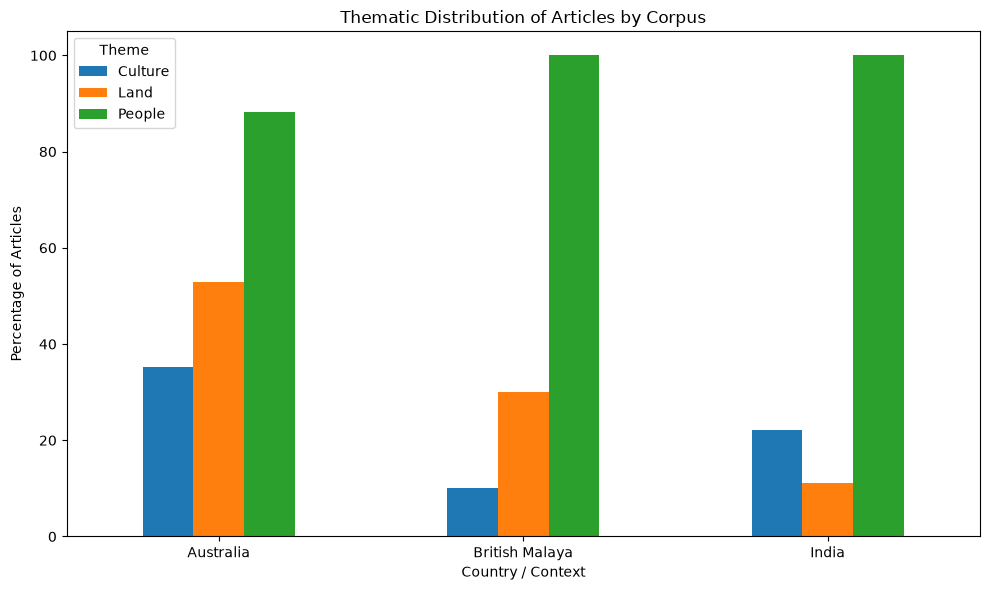

In [29]:
import matplotlib.pyplot as plt

# Reshape data for plotting
theme_plot = theme_df.pivot(
    index="country",
    columns="theme",
    values="percentage_of_country_articles"
)

ax = theme_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Thematic Distribution of Articles by Corpus")
ax.set_xlabel("Country / Context")
ax.set_ylabel("Percentage of Articles")
ax.legend(title="Theme")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [30]:
from collections import Counter
import pandas as pd

# Combine all cleaned tokens within each country/context.
# This gives us one document per corpus.

country_documents = {}

for country in sorted(analysis_df["country"].unique()):
    country_tokens = [
        word
        for tokens in analysis_df.loc[
            analysis_df["country"] == country,
            "clean_tokens"
        ]
        for word in tokens
    ]
    
    country_documents[country] = " ".join(country_tokens)

print("Country-level documents created:")
for country, text in country_documents.items():
    print(f"{country}: {len(text.split())} tokens")

Country-level documents created:
Australia: 2900 tokens
British Malaya: 3178 tokens
India: 2302 tokens


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Treat each country/context as one document.
vectorizer = TfidfVectorizer(
    lowercase=False,
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z'-]*\b"
)

countries = list(country_documents.keys())
documents = [country_documents[country] for country in countries]

tfidf_matrix = vectorizer.fit_transform(documents)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=countries,
    columns=vectorizer.get_feature_names_out()
)

print("TF-IDF matrix shape:", tfidf_df.shape)

TF-IDF matrix shape: (3, 3611)


In [32]:
for country in countries:
    print("\n" + "=" * 60)
    print(country)
    print("=" * 60)
    
    top_words = (
        tfidf_df.loc[country]
        .sort_values(ascending=False)
        .head(20)
    )
    
    for word, score in top_words.items():
        print(f"{word:<20} {score:.4f}")


Australia
aborigines           0.3492
native               0.2669
white                0.2029
natives              0.1868
new                  0.1829
said                 0.1387
would                0.1324
aboriginal           0.1299
camp                 0.1281
one                  0.1072
reserves             0.1068
territory            0.1068
river                0.1068
darwin               0.1068
officers             0.0974
government           0.0946
made                 0.0883
patten               0.0854
station              0.0854
policy               0.0757

British Malaya
malaya               0.3389
malay                0.2592
times                0.1894
malays               0.1794
malayan              0.1595
british              0.1516
country              0.1472
indians              0.1441
india                0.1365
chinese              0.1296
indian               0.1289
would                0.1119
sir                  0.1061
people               0.1001
labour               

In [33]:
# Calculate the number of analyzed tokens represented by each theme
# within each country/context.
#
# Articles may have multiple themes, so the same article can
# contribute tokens to more than one thematic category.

theme_token_results = []

for country in sorted(analysis_df["country"].unique()):
    
    country_df = analysis_df[
        analysis_df["country"] == country
    ]
    
    for theme in ["People", "Land", "Culture"]:
        
        theme_mask = country_df["theme"].fillna("").apply(
            lambda x: theme in [t.strip() for t in x.split(";")]
        )
        
        theme_articles = country_df[theme_mask]
        
        token_count = theme_articles["clean_tokens"].apply(len).sum()
        
        theme_token_results.append({
            "country": country,
            "theme": theme,
            "articles": len(theme_articles),
            "clean_tokens": token_count
        })

theme_token_df = pd.DataFrame(theme_token_results)

print(theme_token_df.to_string(index=False))

       country   theme  articles  clean_tokens
     Australia  People        15          2214
     Australia    Land         9          2244
     Australia Culture         6          1898
British Malaya  People        10          3178
British Malaya    Land         3          1359
British Malaya Culture         1           501
         India  People         9          2302
         India    Land         1            91
         India Culture         2           442


In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Build one People-themed document for each country.
# Each document contains all cleaned tokens from articles
# labelled with the People theme.

people_documents = {}

for country in sorted(analysis_df["country"].unique()):
    
    country_df = analysis_df[
        analysis_df["country"] == country
    ]
    
    people_mask = country_df["theme"].fillna("").apply(
        lambda x: "People" in [t.strip() for t in x.split(";")]
    )
    
    people_tokens = [
        word
        for tokens in country_df.loc[people_mask, "clean_tokens"]
        for word in tokens
    ]
    
    people_documents[country] = " ".join(people_tokens)

people_countries = list(people_documents.keys())
people_texts = [people_documents[country] for country in people_countries]

print("People-themed corpus sizes:")

for country, text in people_documents.items():
    print(f"{country}: {len(text.split())} tokens")

People-themed corpus sizes:
Australia: 2214 tokens
British Malaya: 3178 tokens
India: 2302 tokens


In [35]:
# Calculate TF-IDF for the People-themed documents

people_vectorizer = TfidfVectorizer(
    lowercase=False,
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z'-]*\b"
)

people_matrix = people_vectorizer.fit_transform(people_texts)

people_tfidf_df = pd.DataFrame(
    people_matrix.toarray(),
    index=people_countries,
    columns=people_vectorizer.get_feature_names_out()
)

print("People TF-IDF matrix shape:", people_tfidf_df.shape)

People TF-IDF matrix shape: (3, 3331)


In [36]:
# Display the 20 most distinctive People-related words
# for each country/context.

for country in people_countries:
    
    print("\n" + "=" * 60)
    print(country)
    print("=" * 60)
    
    top_words = (
        people_tfidf_df.loc[country]
        .sort_values(ascending=False)
        .head(20)
    )
    
    for word, score in top_words.items():
        print(f"{word:<20} {score:.4f}")


Australia
aborigines           0.3999
native               0.2690
white                0.2201
new                  0.2094
said                 0.1589
aboriginal           0.1488
would                0.1300
territory            0.1223
darwin               0.1223
reserves             0.1223
natives              0.1209
officers             0.1116
government           0.1083
station              0.0978
patten               0.0978
one                  0.0939
policy               0.0867
made                 0.0867
wales                0.0856
compound             0.0856

British Malaya
malaya               0.3373
malay                0.2580
times                0.1885
malays               0.1786
malayan              0.1588
british              0.1509
country              0.1465
indians              0.1434
india                0.1358
chinese              0.1290
indian               0.1283
would                0.1113
sir                  0.1056
people               0.0996
labour               

In [37]:
# Build one Land-themed document for each country.
# Articles may also carry other themes.

land_documents = {}

for country in sorted(analysis_df["country"].unique()):
    
    country_df = analysis_df[
        analysis_df["country"] == country
    ]
    
    land_mask = country_df["theme"].fillna("").apply(
        lambda x: "Land" in [t.strip() for t in x.split(";")]
    )
    
    land_tokens = [
        word
        for tokens in country_df.loc[land_mask, "clean_tokens"]
        for word in tokens
    ]
    
    land_documents[country] = " ".join(land_tokens)

land_countries = list(land_documents.keys())
land_texts = [land_documents[country] for country in land_countries]

print("Land-themed corpus sizes:")

for country, text in land_documents.items():
    print(f"{country}: {len(text.split())} tokens")

Land-themed corpus sizes:
Australia: 2244 tokens
British Malaya: 1359 tokens
India: 91 tokens


In [38]:
# Calculate TF-IDF for the Land-themed documents

land_vectorizer = TfidfVectorizer(
    lowercase=False,
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z'-]*\b"
)

land_matrix = land_vectorizer.fit_transform(land_texts)

land_tfidf_df = pd.DataFrame(
    land_matrix.toarray(),
    index=land_countries,
    columns=land_vectorizer.get_feature_names_out()
)

print("Land TF-IDF matrix shape:", land_tfidf_df.shape)

Land TF-IDF matrix shape: (3, 2003)


In [39]:
# Display the 20 most distinctive Land-related words
# for each country/context.

for country in land_countries:
    
    print("\n" + "=" * 60)
    print(country)
    print("=" * 60)
    
    top_words = (
        land_tfidf_df.loc[country]
        .sort_values(ascending=False)
        .head(20)
    )
    
    for word, score in top_words.items():
        print(f"{word:<20} {score:.4f}")


Australia
native               0.2727
aborigines           0.2609
natives              0.1804
new                  0.1804
white                0.1660
camp                 0.1423
said                 0.1353
river                0.1186
night                0.1186
aboriginal           0.1186
would                0.1172
officers             0.1082
one                  0.1082
affairs              0.1067
man                  0.1067
made                 0.0992
us                   0.0992
station              0.0949
reserves             0.0949
training             0.0949

British Malaya
malay                0.3105
times                0.2451
malays               0.2288
british              0.1798
would                0.1740
padi                 0.1634
non-malays           0.1634
sir                  0.1634
rice                 0.1471
shenton              0.1307
year                 0.1243
lands                0.1144
present              0.1119
per                  0.1119
lb                   

In [40]:
# Inspect very short tokens across the entire corpus.
# These can reveal OCR fragments, initials, and isolated characters.

short_token_counts = Counter(
    word
    for tokens in analysis_df["clean_tokens"]
    for word in tokens
    if len(word) <= 2
)

print(f"Unique tokens of length <= 2: {len(short_token_counts)}")
print(f"Total tokens of length <= 2: {sum(short_token_counts.values())}")

print("\nMost frequent short tokens:")
for word, count in short_token_counts.most_common(100):
    print(f"{word:<10} {count}")

Unique tokens of length <= 2: 29
Total tokens of length <= 2: 138

Most frequent short tokens:
us         34
f.         11
lb         9
go         8
c.         8
p.         5
t.         5
g.         5
w.         5
u.         4
b.         4
v.         4
n.         4
r.         4
j.         4
la         4
h.         3
e.         3
k.         2
y.         2
de         2
rs         1
b          1
i.         1
n          1
iv         1
ii         1
o.         1
e          1


In [41]:
# Find unusually long tokens that may contain multiple words
# joined together by OCR errors.

long_tokens = Counter(
    word
    for tokens in analysis_df["clean_tokens"]
    for word in tokens
    if len(word) >= 20
)

print(f"Unique tokens with 20+ characters: {len(long_tokens)}")
print(f"Total tokens with 20+ characters: {sum(long_tokens.values())}")

print("\nLongest / most frequent long tokens:")
for word, count in sorted(
    long_tokens.items(),
    key=lambda x: (-len(x[0]), -x[1])
)[:100]:
    print(f"{word:<40} {count}")

Unique tokens with 20+ characters: 0
Total tokens with 20+ characters: 0

Longest / most frequent long tokens:


In [42]:
# Final artifact audit after OCR-spacing corrections

import re
from collections import Counter

all_clean_words = [
    word
    for tokens in analysis_df["clean_tokens"]
    for word in tokens
]

# 1. Single-letter alphabetic tokens
single_letters = Counter(
    word
    for word in all_clean_words
    if re.fullmatch(r"[a-z]", word)
)

# 2. Very short tokens (1–2 characters)
short_tokens = Counter(
    word
    for word in all_clean_words
    if len(word) <= 2
)

# 3. Tokens containing digits
digit_tokens = Counter(
    word
    for word in all_clean_words
    if any(char.isdigit() for char in word)
)

# 4. Tokens containing unusual punctuation
punctuation_tokens = Counter(
    word
    for word in all_clean_words
    if re.search(r"[^a-zA-Z'-]", word)
)

# 5. Very long tokens
long_tokens = Counter(
    word
    for word in all_clean_words
    if len(word) >= 20
)

print("=" * 60)
print("FINAL OCR ARTIFACT AUDIT")
print("=" * 60)

print("\n1. Single-letter alphabetic tokens")
print(f"Unique: {len(single_letters)}")
print(f"Total: {sum(single_letters.values())}")
print(single_letters.most_common(50))

print("\n2. Short tokens (1–2 characters)")
print(f"Unique: {len(short_tokens)}")
print(f"Total: {sum(short_tokens.values())}")
print(short_tokens.most_common(50))

print("\n3. Tokens containing digits")
print(f"Unique: {len(digit_tokens)}")
print(f"Total: {sum(digit_tokens.values())}")
print(digit_tokens.most_common(50))

print("\n4. Tokens containing unusual punctuation")
print(f"Unique: {len(punctuation_tokens)}")
print(f"Total: {sum(punctuation_tokens.values())}")
print(punctuation_tokens.most_common(50))

print("\n5. Very long tokens (20+ characters)")
print(f"Unique: {len(long_tokens)}")
print(f"Total: {sum(long_tokens.values())}")
print(long_tokens.most_common(50))

FINAL OCR ARTIFACT AUDIT

1. Single-letter alphabetic tokens
Unique: 3
Total: 3
[('b', 1), ('n', 1), ('e', 1)]

2. Short tokens (1–2 characters)
Unique: 29
Total: 138
[('us', 34), ('f.', 11), ('lb', 9), ('go', 8), ('c.', 8), ('p.', 5), ('t.', 5), ('g.', 5), ('w.', 5), ('u.', 4), ('b.', 4), ('v.', 4), ('n.', 4), ('r.', 4), ('j.', 4), ('la', 4), ('h.', 3), ('e.', 3), ('k.', 2), ('y.', 2), ('de', 2), ('rs', 1), ('b', 1), ('i.', 1), ('n', 1), ('iv', 1), ('ii', 1), ('o.', 1), ('e', 1)]

3. Tokens containing digits
Unique: 2
Total: 2
[('14th', 1), ('30th', 1)]

4. Tokens containing unusual punctuation
Unique: 36
Total: 108
[('f.', 11), ('c.', 8), ('p.', 5), ('t.', 5), ('g.', 5), ('w.', 5), ('etc.', 5), ('jan.', 5), ('u.', 4), ('b.', 4), ('v.', 4), ('n.', 4), ('r.', 4), ('j.', 4), ('dr.', 4), ('h.', 3), ('e.', 3), ('st.', 3), ('k.', 2), ('p.m.', 2), ('y.', 2), ('thomson.', 2), ('e.g', 1), ('legislations.', 1), ('community.', 1), ('14th', 1), ('i.', 1), ('hill.', 1), ('o.', 1), ('ft.', 1), ('r

In [43]:
# Final corpus statistics
# Calculated from the current, locked preprocessing results.

print("=" * 60)
print("FINAL CORPUS STATISTICS")
print("=" * 60)

# Article count
print(f"\nArticles: {len(analysis_df)}")

# Raw word counts from the current article texts
raw_word_counts = []

for text in analysis_df["text"]:
    # Exclude the first line containing the article heading
    lines = text.splitlines()
    body = "\n".join(lines[1:]).strip() if len(lines) > 1 else text
    raw_word_counts.append(len(body.split()))

total_raw_words = sum(raw_word_counts)

# Clean token statistics
total_clean_tokens = sum(
    len(tokens) for tokens in analysis_df["clean_tokens"]
)

unique_clean_words = len(set(all_clean_words))

print(f"Total raw words: {total_raw_words:,}")
print(f"Total clean tokens: {total_clean_tokens:,}")
print(f"Unique clean word types: {unique_clean_words:,}")

# Articles by country
print("\nArticles by country:")
article_counts = (
    analysis_df["country"]
    .value_counts()
    .sort_index()
)
print(article_counts)

# Clean tokens by country
print("\nClean tokens by country:")
country_token_counts = (
    analysis_df.groupby("country")["clean_tokens"]
    .apply(lambda x: sum(len(tokens) for tokens in x))
    .sort_index()
)
print(country_token_counts)

# Average clean tokens per article
print("\nAverage clean tokens per article:")
average_tokens = (
    country_token_counts / article_counts
)
print(average_tokens.round(1))

FINAL CORPUS STATISTICS

Articles: 36
Total raw words: 15,971
Total clean tokens: 8,380
Unique clean word types: 3,625

Articles by country:
country
Australia         17
British Malaya    10
India              9
Name: count, dtype: int64

Clean tokens by country:
country
Australia         2900
British Malaya    3178
India             2302
Name: clean_tokens, dtype: int64

Average clean tokens per article:
country
Australia         170.6
British Malaya    317.8
India             255.8
dtype: float64


In [44]:
# Country-level word frequencies
# Uses the final clean_tokens from the locked preprocessing pipeline.

from collections import Counter

country_frequencies = {}

for country in analysis_df["country"].unique():
    country_words = [
        word
        for tokens in analysis_df.loc[
            analysis_df["country"] == country, "clean_tokens"
        ]
        for word in tokens
    ]
    
    country_frequencies[country] = Counter(country_words)

# Display the 30 most frequent words for each country
for country, counts in country_frequencies.items():
    print("=" * 60)
    print(country.upper())
    print("=" * 60)
    
    for word, count in counts.most_common(30):
        print(f"{word:<20} {count}")
    
    print()

INDIA
congress             24
tribes               20
india                18
government           15
aboriginal           12
people               12
conference           12
resolution           10
areas                10
may                  10
must                 10
ministry             9
district             9
said                 9
freedom              9
world                9
message              9
assam                9
inquiry              8
report               8
new                  8
us                   8
whole                8
indian               8
buddha               8
muslim               8
bombay               7
time                 7
excluded             7
two                  7

AUSTRALIA
aborigines           43
new                  29
native               25
natives              23
said                 22
would                21
white                19
one                  17
aboriginal           16
government           15
made                 14
policy            

In [45]:
# Normalized word frequencies by country
# Frequency is reported per 1,000 clean tokens.

normalized_rows = []

for country, counts in country_frequencies.items():
    total_tokens = sum(counts.values())
    
    for word, count in counts.items():
        normalized_rows.append({
            "country": country,
            "word": word,
            "count": count,
            "tokens": total_tokens,
            "per_1000": (count / total_tokens) * 1000
        })

normalized_df = pd.DataFrame(normalized_rows)

# Display the 30 most frequent normalized terms for each country
for country in normalized_df["country"].unique():
    country_df = (
        normalized_df[normalized_df["country"] == country]
        .sort_values("per_1000", ascending=False)
        .head(30)
    )
    
    print("=" * 60)
    print(country.upper())
    print("=" * 60)
    
    for _, row in country_df.iterrows():
        print(
            f"{row['word']:<20} "
            f"{row['per_1000']:.2f} per 1,000 "
            f"({int(row['count'])})"
        )
    
    print()

INDIA
congress             10.43 per 1,000 (24)
tribes               8.69 per 1,000 (20)
india                7.82 per 1,000 (18)
government           6.52 per 1,000 (15)
conference           5.21 per 1,000 (12)
aboriginal           5.21 per 1,000 (12)
people               5.21 per 1,000 (12)
areas                4.34 per 1,000 (10)
must                 4.34 per 1,000 (10)
may                  4.34 per 1,000 (10)
resolution           4.34 per 1,000 (10)
assam                3.91 per 1,000 (9)
message              3.91 per 1,000 (9)
world                3.91 per 1,000 (9)
district             3.91 per 1,000 (9)
freedom              3.91 per 1,000 (9)
said                 3.91 per 1,000 (9)
ministry             3.91 per 1,000 (9)
muslim               3.48 per 1,000 (8)
inquiry              3.48 per 1,000 (8)
report               3.48 per 1,000 (8)
buddha               3.48 per 1,000 (8)
us                   3.48 per 1,000 (8)
new                  3.48 per 1,000 (8)
whole                3

In [46]:
# TF-IDF by country
# Each country is treated as one document.
# Terms that are common within one country but less common
# across the other countries receive higher TF-IDF scores.

from sklearn.feature_extraction.text import TfidfVectorizer

# Combine all clean tokens belonging to each country
country_documents = (
    analysis_df
    .groupby("country")["clean_tokens"]
    .apply(lambda articles: " ".join(
        word
        for tokens in articles
        for word in tokens
    ))
)

# Create TF-IDF representation
vectorizer = TfidfVectorizer(
    lowercase=False,
    token_pattern=r"(?u)\b[\w'-]+\b"
)

tfidf_matrix = vectorizer.fit_transform(country_documents)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=country_documents.index,
    columns=vectorizer.get_feature_names_out()
)

# Display the 20 highest TF-IDF terms for each country
for country in tfidf_df.index:
    top_terms = (
        tfidf_df.loc[country]
        .sort_values(ascending=False)
        .head(20)
    )
    
    print("=" * 60)
    print(country.upper())
    print("=" * 60)
    
    for word, score in top_terms.items():
        print(f"{word:<20} {score:.4f}")
    
    print()

AUSTRALIA
aborigines           0.3492
native               0.2669
white                0.2029
natives              0.1868
new                  0.1829
said                 0.1387
would                0.1324
aboriginal           0.1299
camp                 0.1281
one                  0.1072
river                0.1068
reserves             0.1068
darwin               0.1068
territory            0.1068
officers             0.0974
government           0.0946
made                 0.0883
patten               0.0854
station              0.0854
leave                0.0757

BRITISH MALAYA
malaya               0.3389
malay                0.2592
times                0.1894
malays               0.1794
malayan              0.1595
british              0.1516
country              0.1472
indians              0.1440
india                0.1365
chinese              0.1296
indian               0.1289
would                0.1119
sir                  0.1061
people               0.1001
labour               0

In [47]:
# Distinctive keywords by country
#
# Uses a smoothed log-odds ratio to identify words that are
# disproportionately associated with each country's corpus.
#
# A minimum frequency of 3 across the full corpus is used
# to reduce the influence of one-off names and OCR noise.

import math
from collections import Counter

# Build word counts for each country
country_word_counts = {}

for country in analysis_df["country"].unique():
    words = [
        word
        for tokens in analysis_df.loc[
            analysis_df["country"] == country, "clean_tokens"
        ]
        for word in tokens
    ]
    
    country_word_counts[country] = Counter(words)

# Total word counts across the corpus
total_country_counts = {
    country: sum(counts.values())
    for country, counts in country_word_counts.items()
}

# Combined vocabulary
vocabulary = set(
    word
    for counts in country_word_counts.values()
    for word in counts
)

# Only retain words appearing at least 3 times overall
vocabulary = {
    word
    for word in vocabulary
    if sum(
        country_word_counts[country].get(word, 0)
        for country in country_word_counts
    ) >= 3
}

# Calculate smoothed log-odds
distinctive_results = {}

countries = list(country_word_counts.keys())

for country in countries:
    other_countries = [
        c for c in countries
        if c != country
    ]
    
    # Combine the other two countries
    other_counts = Counter()
    for other_country in other_countries:
        other_counts.update(country_word_counts[other_country])
    
    country_total = total_country_counts[country]
    other_total = sum(other_counts.values())
    
    results = []
    
    for word in vocabulary:
        country_count = country_word_counts[country].get(word, 0)
        other_count = other_counts.get(word, 0)
        
        # Add-one smoothing
        country_rate = (
            (country_count + 1) /
            (country_total + 2)
        )
        
        other_rate = (
            (other_count + 1) /
            (other_total + 2)
        )
        
        log_odds = math.log(country_rate / other_rate)
        
        results.append({
            "word": word,
            "count_country": country_count,
            "count_other": other_count,
            "log_odds": log_odds
        })
    
    distinctive_results[country] = pd.DataFrame(results).sort_values(
        "log_odds",
        ascending=False
    )

# Display the 25 most distinctive words for each country
for country in countries:
    print("=" * 60)
    print(country.upper())
    print("=" * 60)
    
    top_words = distinctive_results[country].head(25)
    
    for _, row in top_words.iterrows():
        print(
            f"{row['word']:<20} "
            f"log-odds: {row['log_odds']:.3f} "
            f"(country: {int(row['count_country'])}, "
            f"other: {int(row['count_other'])})"
        )
    
    print()

INDIA
congress             log-odds: 3.496 (country: 24, other: 1)
assam                log-odds: 3.273 (country: 9, other: 0)
message              log-odds: 3.273 (country: 9, other: 0)
muslim               log-odds: 3.168 (country: 8, other: 0)
buddha               log-odds: 3.168 (country: 8, other: 0)
excluded             log-odds: 3.050 (country: 7, other: 0)
bombay               log-odds: 3.050 (country: 7, other: 0)
strikers             log-odds: 2.916 (country: 6, other: 0)
backward             log-odds: 2.916 (country: 6, other: 0)
conference           log-odds: 2.842 (country: 12, other: 1)
partially            log-odds: 2.762 (country: 5, other: 0)
urged                log-odds: 2.762 (country: 5, other: 0)
thana                log-odds: 2.762 (country: 5, other: 0)
presidency           log-odds: 2.762 (country: 5, other: 0)
digboi               log-odds: 2.762 (country: 5, other: 0)
relief               log-odds: 2.762 (country: 5, other: 0)
ceylon               log-odds: 2

In [48]:
# Word frequencies by country and theme
#
# Articles with multiple themes are included in each applicable theme.
# This allows us to examine the vocabulary associated with
# People, Land, and Culture within each country.

theme_rows = []

for _, row in analysis_df.iterrows():
    themes = [
        theme.strip()
        for theme in row["theme"].split(";")
    ]
    
    for theme in themes:
        for token in row["clean_tokens"]:
            theme_rows.append({
                "country": row["country"],
                "theme": theme,
                "word": token
            })

theme_words_df = pd.DataFrame(theme_rows)

theme_frequencies = (
    theme_words_df
    .groupby(["country", "theme", "word"])
    .size()
    .reset_index(name="count")
)

# Display the top 20 words for each country × theme combination
for country in analysis_df["country"].unique():
    for theme in ["People", "Land", "Culture"]:
        
        subset = (
            theme_frequencies[
                (theme_frequencies["country"] == country) &
                (theme_frequencies["theme"] == theme)
            ]
            .sort_values("count", ascending=False)
            .head(20)
        )
        
        if len(subset) == 0:
            continue
        
        print("=" * 60)
        print(f"{country.upper()} — {theme.upper()}")
        print("=" * 60)
        
        for _, item in subset.iterrows():
            print(f"{item['word']:<20} {int(item['count'])}")
        
        print()

INDIA — PEOPLE
congress             24
tribes               20
india                18
government           15
people               12
conference           12
aboriginal           12
must                 10
may                  10
areas                10
resolution           10
said                 9
world                9
assam                9
message              9
freedom              9
district             9
ministry             9
muslim               8
new                  8

INDIA — LAND
remission            4
premier              3
zamindars            2
government           2
pandit               2
realised             2
p.                   2
congress             2
bill                 2
united               2
tenants              2
pant                 2
rent                 2
assembly             1
assumption           1
ballabh              1
amount               1
allegations          1
adding               1
actuated             1

INDIA — CULTURE
message              9


In [49]:
# Normalized word frequencies by country and theme
#
# Frequencies are reported per 1,000 clean tokens contained
# in articles assigned to each country/theme combination.

theme_normalized_rows = []

for (country, theme), group in theme_words_df.groupby(
    ["country", "theme"]
):
    word_counts = Counter(group["word"])
    total_tokens = len(group)

    for word, count in word_counts.items():
        theme_normalized_rows.append({
            "country": country,
            "theme": theme,
            "word": word,
            "count": count,
            "tokens": total_tokens,
            "per_1000": (count / total_tokens) * 1000
        })

theme_normalized_df = pd.DataFrame(theme_normalized_rows)

# Display top 20 normalized terms for each country × theme
for country in ["India", "Australia", "British Malaya"]:
    for theme in ["People", "Land", "Culture"]:

        subset = (
            theme_normalized_df[
                (theme_normalized_df["country"] == country) &
                (theme_normalized_df["theme"] == theme)
            ]
            .sort_values("per_1000", ascending=False)
            .head(20)
        )

        if subset.empty:
            continue

        print("=" * 60)
        print(f"{country.upper()} — {theme.upper()}")
        print("=" * 60)

        for _, row in subset.iterrows():
            print(
                f"{row['word']:<20} "
                f"{row['per_1000']:.2f} per 1,000 "
                f"({int(row['count'])})"
            )

        print()

INDIA — PEOPLE
congress             10.43 per 1,000 (24)
tribes               8.69 per 1,000 (20)
india                7.82 per 1,000 (18)
government           6.52 per 1,000 (15)
conference           5.21 per 1,000 (12)
aboriginal           5.21 per 1,000 (12)
people               5.21 per 1,000 (12)
areas                4.34 per 1,000 (10)
must                 4.34 per 1,000 (10)
may                  4.34 per 1,000 (10)
resolution           4.34 per 1,000 (10)
assam                3.91 per 1,000 (9)
message              3.91 per 1,000 (9)
world                3.91 per 1,000 (9)
district             3.91 per 1,000 (9)
freedom              3.91 per 1,000 (9)
said                 3.91 per 1,000 (9)
ministry             3.91 per 1,000 (9)
muslim               3.48 per 1,000 (8)
inquiry              3.48 per 1,000 (8)

INDIA — LAND
remission            43.96 per 1,000 (4)
premier              32.97 per 1,000 (3)
p.                   21.98 per 1,000 (2)
united               21.98 per 1,000

In [50]:
# Concordance analysis: selected term in context
#
# Shows sentences containing a target word so that we can examine
# how the term is used in its historical context.

target_term = "native"

for _, row in analysis_df[
    analysis_df["country"] == "Australia"
].iterrows():

    text = row["text"]

    sentences = re.split(r'(?<=[.!?])\s+', text)

    matches = [
        sentence.strip()
        for sentence in sentences
        if re.search(
            rf'\b{re.escape(target_term)}\b',
            sentence,
            flags=re.IGNORECASE
        )
    ]

    if matches:
        print("=" * 70)
        print(f"{row['article_id']} — {row['title']}")
        print("=" * 70)

        for sentence in matches:
            print(sentence)
            print()

AUS03 — New Deal For Natives
Elaborate schemes for a "new deal" for the aborigines are old as the history of white occupation, and however well-meaning the latest Commonwealth proposal may be, it offers little hope of averting the continued destruction of the native race.

Such every civilised native has been in Australia since.

Those who really know the temperament and psychology of the Australian black—not from observation in institutions or missions or reserves on the outskirts of towns, where he is a pale shadow of the true aboriginal—but in his native wildwood, still a man—preserve a baffled silence when the old, old problem makes copy, in recrimination and absurd suggestion.

His love of his native earth, and his knowledge of it, are a lesson to us.

Native prisons are a Bastille of unconscious cruelty, the unfortunates condemned for crimes of which they have no knowledge.

Native Courts are a travesty of justice.

They must be forbidden ground to all intruders, white or black, 

In [51]:
# Concordance analysis: "government"
#
# Displays sentences containing "government" for each country.

target_term = "government"

for country in ["India", "British Malaya", "Australia"]:

    print("\n" + "=" * 70)
    print(f"{country.upper()}")
    print("=" * 70)

    country_df = analysis_df[
        analysis_df["country"] == country
    ]

    for _, row in country_df.iterrows():

        text = row["text"]

        sentences = re.split(
            r'(?<=[.!?])\s+',
            text
        )

        matches = [
            sentence.strip()
            for sentence in sentences
            if re.search(
                rf'\b{re.escape(target_term)}\b',
                sentence,
                flags=re.IGNORECASE
            )
        ]

        if matches:
            print(f"\n{row['article_id']} — {row['title']}\n")

            for sentence in matches:
                print(sentence)
                print()


INDIA

IND01 — Uplift Of Hill Tribes

It is an "amputation of the body politic." The first official inquiry into the conditions of the Aboriginal and Hill Tribes of the Bombay Presidency was carried on by the Starte Committee appointed by the Government in 1928 on the recommendation of Mr.

In a sense he tries to justify in an apologetic tone the polity underlying the Government of India Act of 1935 with regard to the "Excluded Areas".

It is only the popularly controlled Government, the Congress Ministry, which alone can take ameliorative measures for these Tribes.

To justify the demarcation of Partially Excluded Areas on the ground that "it offers an extremely convenient vehicle from administrative point of view for Government to pull up the backward classes and backward areas on their feet" we have by now learnt at a great cost to ourselves what mischief separate electorate and nominations, devised for the protection of minorities, has played so far.

It is unthinkable that Govern

In [52]:
# Concordance analysis: "people"
#
# Displays sentences containing "people" for each country.

target_term = "people"

for country in ["India", "British Malaya", "Australia"]:

    print("\n" + "=" * 70)
    print(f"{country.upper()}")
    print("=" * 70)

    country_df = analysis_df[
        analysis_df["country"] == country
    ]

    for _, row in country_df.iterrows():

        text = row["text"]

        sentences = re.split(
            r'(?<=[.!?])\s+',
            text
        )

        matches = [
            sentence.strip()
            for sentence in sentences
            if re.search(
                rf'\b{re.escape(target_term)}\b',
                sentence,
                flags=re.IGNORECASE
            )
        ]

        if matches:
            print(f"\n{row['article_id']} — {row['title']}\n")

            for sentence in matches:
                print(sentence)
                print()


INDIA

IND01 — Uplift Of Hill Tribes

Therefore it may be relied upon to do the utmost for the welfare of these tribes, so none knows better the hardships of these people than the elected representative from these tracts.

While trying to devise means for the uplift of these Aboriginal Tribes we must be careful to see that these measures do not tend to perpetuate the separateness of these tribes, but in course of time obliterate the difference, eventually bringing the backward tribes in line with the other people.


IND04 — Narrow Provincialism Deplored

He urged the people to realise that what the Congress had achieved to-day was the result of a long struggle and that unless every Indian co-operated with the Congress it would not be possible to use the present position and strength for further advancement towards the goal.

Bhagwat, Congress Socialist from Bhiwandi, opposed the resolution on the ground that the granting of freedom to form groups within the Congress would strengthen t

In [54]:
# Article-boundary-safe collocation analysis around "government"
#
# Counts words appearing within a window of 5 tokens
# on either side of "government".
#
# Each article is analysed separately so that words from
# different articles can never become artificial neighbours.

from collections import Counter

target_term = "government"
window_size = 5

for country in ["India", "British Malaya", "Australia"]:

    collocations = Counter()

    country_df = analysis_df[
        analysis_df["country"] == country
    ]

    for _, row in country_df.iterrows():

        tokens = row["clean_tokens"]

        for i, token in enumerate(tokens):

            if token == target_term:

                start = max(0, i - window_size)
                end = min(
                    len(tokens),
                    i + window_size + 1
                )

                context = tokens[start:end]

                for word in context:
                    if word != target_term:
                        collocations[word] += 1

    print("=" * 60)
    print(f"{country.upper()} — COLLOCATIONS WITH '{target_term}'")
    print("=" * 60)

    for word, count in collocations.most_common(20):
        print(f"{word:<20} {count}")

    print()

INDIA — COLLOCATIONS WITH 'government'
free                 3
india                2
areas                2
congress             2
take                 2
backward             2
per                  2
remission            2
responsibility       2
district             2
urged                2
must                 2
existence            2
centre               2
though               2
fully                2
presidency           1
carried              1
starte               1
committee            1

BRITISH MALAYA — COLLOCATIONS WITH 'government'
indian               8
malay                5
labour               4
malaya               4
malayan              4
would                3
monopoly             2
peasants             2
misunderstanding     2
far                  2
upon                 2
want                 2
every                2
education            2
health               2
estate               2
indians              1
states               1
policy               1
british        

In [55]:
# Distinctive vocabulary by theme within each country
#
# Uses smoothed log-odds to identify words that are more
# characteristic of one theme than the other.
#
# Articles with multiple themes contribute to each applicable
# theme, consistent with the corpus design.

from collections import Counter
import math

min_frequency = 3
alpha = 0.01

def get_theme_counts(country, theme):
    subset = analysis_df[
        (analysis_df["country"] == country) &
        (analysis_df["theme"].str.contains(
            theme,
            regex=False,
            na=False
        ))
    ]

    counts = Counter()

    for tokens in subset["clean_tokens"]:
        counts.update(tokens)

    return counts


def log_odds(counts_a, counts_b, alpha=0.01):
    total_a = sum(counts_a.values())
    total_b = sum(counts_b.values())

    vocabulary = set(counts_a) | set(counts_b)

    results = []

    for word in vocabulary:

        a = counts_a[word]
        b = counts_b[word]

        if a + b < min_frequency:
            continue

        logit_a = math.log(
            (a + alpha) /
            (total_a - a + alpha)
        )

        logit_b = math.log(
            (b + alpha) /
            (total_b - b + alpha)
        )

        score = logit_a - logit_b

        results.append({
            "word": word,
            "score": score,
            "count_a": a,
            "count_b": b
        })

    return sorted(
        results,
        key=lambda x: x["score"],
        reverse=True
    )


for country in ["India", "British Malaya", "Australia"]:

    print("\n" + "=" * 70)
    print(f"{country.upper()} — DISTINCTIVE THEME VOCABULARY")
    print("=" * 70)

    theme_pairs = [
        ("People", "Land"),
        ("People", "Culture"),
        ("Land", "Culture")
    ]

    for theme_a, theme_b in theme_pairs:

        counts_a = get_theme_counts(country, theme_a)
        counts_b = get_theme_counts(country, theme_b)

        if not counts_a or not counts_b:
            continue

        results = log_odds(counts_a, counts_b)

        print(
            f"\n{theme_a} > {theme_b}"
        )
        print("-" * 50)

        for result in results[:15]:
            print(
                f"{result['word']:<20} "
                f"{result['score']:>7.3f} "
                f"({result['count_a']} vs "
                f"{result['count_b']})"
            )

        print(
            f"\n{theme_b} > {theme_a}"
        )
        print("-" * 50)

        for result in results[-15:][::-1]:
            print(
                f"{result['word']:<20} "
                f"{result['score']:>7.3f} "
                f"({result['count_a']} vs "
                f"{result['count_b']})"
            )


INDIA — DISTINCTIVE THEME VOCABULARY

People > Land
--------------------------------------------------
tribes                 4.380 (20 vs 0)
india                  4.273 (18 vs 0)
conference             3.866 (12 vs 0)
aboriginal             3.866 (12 vs 0)
people                 3.866 (12 vs 0)
may                    3.683 (10 vs 0)
areas                  3.683 (10 vs 0)
must                   3.683 (10 vs 0)
resolution             3.683 (10 vs 0)
world                  3.577 (9 vs 0)
district               3.577 (9 vs 0)
ministry               3.577 (9 vs 0)
assam                  3.577 (9 vs 0)
freedom                3.577 (9 vs 0)
said                   3.577 (9 vs 0)

Land > People
--------------------------------------------------
remission             -3.274 (4 vs 4)
premier               -3.263 (3 vs 3)
pant                  -3.252 (2 vs 2)
realised              -3.252 (2 vs 2)
pandit                -3.252 (2 vs 2)
tenants               -3.252 (2 vs 2)
zamindars             -

In [56]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate percentage of articles assigned to each theme
theme_counts = []

for country in ["India", "British Malaya", "Australia"]:

    country_df = analysis_df[
        analysis_df["country"] == country
    ]

    total_articles = len(country_df)

    for theme in ["People", "Land", "Culture"]:

        count = country_df["theme"].str.contains(
            theme,
            regex=False,
            na=False
        ).sum()

        percentage = (count / total_articles) * 100

        theme_counts.append({
            "country": country,
            "theme": theme,
            "article_count": count,
            "percentage": percentage
        })

theme_df = pd.DataFrame(theme_counts)

print(theme_df)

          country    theme  article_count  percentage
0           India   People              9  100.000000
1           India     Land              1   11.111111
2           India  Culture              2   22.222222
3  British Malaya   People             10  100.000000
4  British Malaya     Land              3   30.000000
5  British Malaya  Culture              1   10.000000
6       Australia   People             15   88.235294
7       Australia     Land              9   52.941176
8       Australia  Culture              6   35.294118


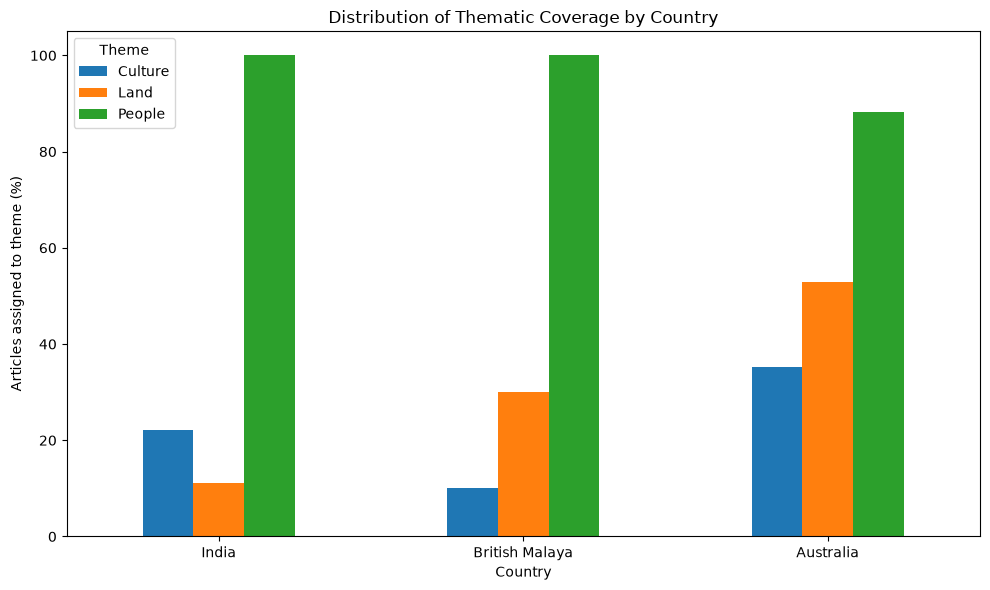

In [57]:
# Reshape for plotting
plot_df = theme_df.pivot(
    index="country",
    columns="theme",
    values="percentage"
)

# Keep country order consistent
plot_df = plot_df.reindex(
    ["India", "British Malaya", "Australia"]
)

# Plot
ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title(
    "Distribution of Thematic Coverage by Country"
)

ax.set_xlabel("Country")
ax.set_ylabel("Articles assigned to theme (%)")

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0
)

ax.legend(
    title="Theme"
)

plt.tight_layout()
plt.show()

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

# Convert cleaned tokens back into documents
documents = analysis_df["clean_tokens"].apply(
    lambda tokens: " ".join(tokens)
)

# TF-IDF at the individual article level
vectorizer = TfidfVectorizer(
    lowercase=False,
    min_df=2,
    max_df=0.80,
    sublinear_tf=True
)

tfidf_matrix = vectorizer.fit_transform(documents)

terms = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=terms,
    index=analysis_df["article_id"]
)

print(f"Articles: {tfidf_df.shape[0]}")
print(f"Vocabulary after filtering: {tfidf_df.shape[1]}")

Articles: 36
Vocabulary after filtering: 1108


In [59]:
# Calculate the mean article-level TF-IDF for each country

tfidf_with_country = tfidf_df.copy()

tfidf_with_country["country"] = (
    analysis_df.set_index("article_id")["country"]
)

country_tfidf = (
    tfidf_with_country
    .groupby("country")
    .mean(numeric_only=True)
)

for country in ["India", "British Malaya", "Australia"]:

    scores = (
        country_tfidf.loc[country]
        .sort_values(ascending=False)
        .head(20)
    )

    print("\n" + "=" * 65)
    print(f"{country.upper()} — ARTICLE-LEVEL TF-IDF")
    print("=" * 65)

    for word, score in scores.items():
        print(f"{word:<20} {score:.4f}")


INDIA — ARTICLE-LEVEL TF-IDF
congress             0.0911
muslim               0.0677
conference           0.0645
india                0.0605
government           0.0583
united               0.0536
ministry             0.0534
district             0.0472
freedom              0.0459
could                0.0457
people               0.0453
hope                 0.0450
press                0.0448
world                0.0429
rent                 0.0417
economic             0.0410
league               0.0406
appeal               0.0390
resolution           0.0386
may                  0.0383

BRITISH MALAYA — ARTICLE-LEVEL TF-IDF
malaya               0.0919
indians              0.0797
malay                0.0718
india                0.0698
times                0.0670
british              0.0660
chinese              0.0659
malays               0.0640
sir                  0.0564
malayan              0.0555
may                  0.0545
general              0.0528
state                0.0516
labour 

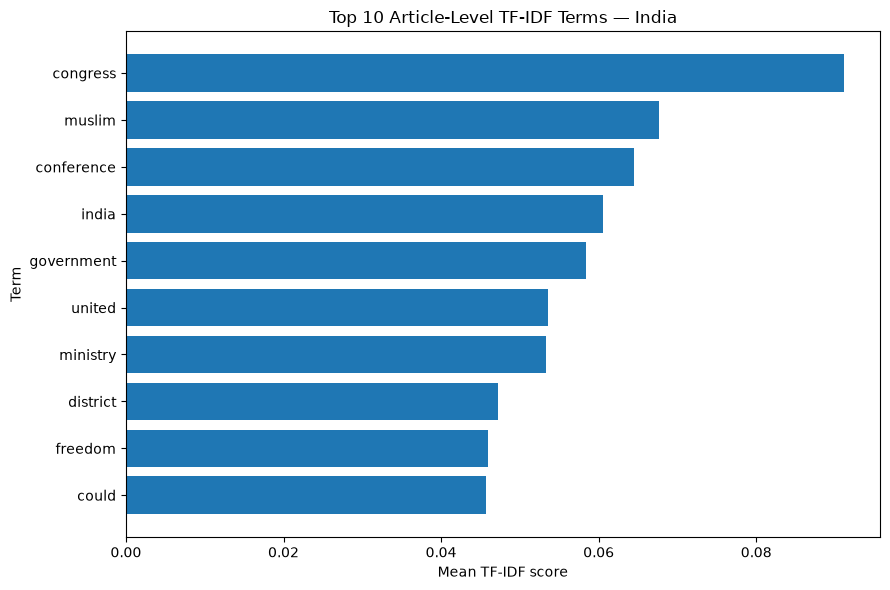

Saved: c:\Users\User\Desktop\colonial-discourse-nlp\results\figures\india_tfidf_top10.png


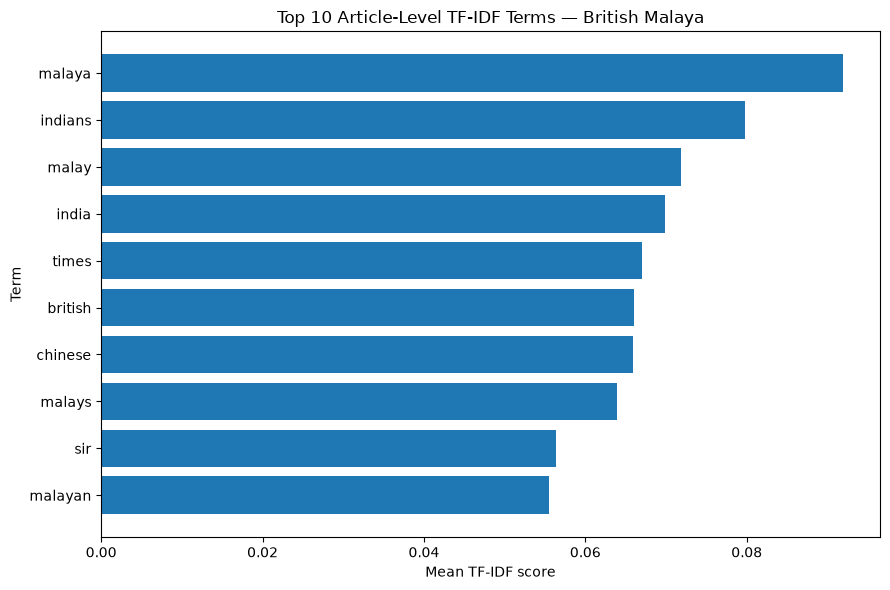

Saved: c:\Users\User\Desktop\colonial-discourse-nlp\results\figures\british_malaya_tfidf_top10.png


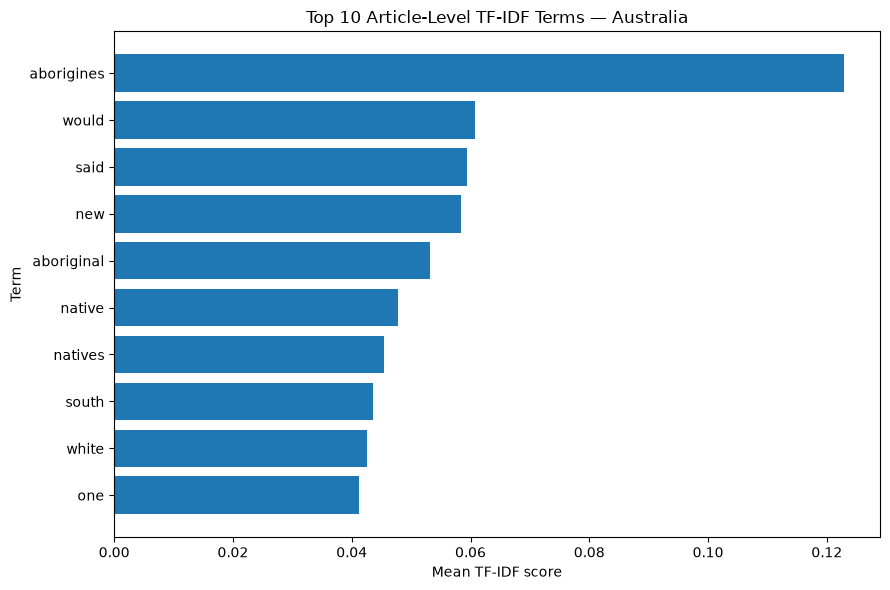

Saved: c:\Users\User\Desktop\colonial-discourse-nlp\results\figures\australia_tfidf_top10.png


In [60]:
import matplotlib.pyplot as plt
from pathlib import Path

# Output directory
FIGURES_DIR = PROJECT_DIR / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Top 10 TF-IDF terms per country
countries = ["India", "British Malaya", "Australia"]

for country in countries:

    scores = (
        country_tfidf.loc[country]
        .sort_values(ascending=False)
        .head(10)
        .sort_values()
    )

    plt.figure(figsize=(9, 6))

    plt.barh(
        scores.index,
        scores.values
    )

    plt.title(
        f"Top 10 Article-Level TF-IDF Terms — {country}"
    )

    plt.xlabel("Mean TF-IDF score")
    plt.ylabel("Term")

    plt.tight_layout()

    # Safe filename
    filename = (
        country.lower()
        .replace(" ", "_")
        + "_tfidf_top10.png"
    )

    output_path = FIGURES_DIR / filename

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved: {output_path}")